# Rozlisenie pokoja a motorickej imaginacie (rest vs MI)

Binarna uloha: **rest (0)** vs **motoricka imaginacia (1)**, kde sa lava a prava ruka zlucuju do spolocnej triedy MI. Cross-session **leave-one-session-out** validacia, len motoricke kanaly (C3, C4, CP3, CP4), filter bank mu + beta, recentrovane kovariancie v tangent space. Porovnavame **LDA, LR, RF**, kazdy **s** aj **bez** rejekcie artefaktov (Riemannian Potato).

Cela logika je v module `mi_pipeline.py`, takze tato uloha aj trojtriedna bezia cez identicky kod a su porovnatelne.

## 1. Nacitanie a predspracovanie

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import mi_pipeline as mi

SESSION_GLOB = "data/session_glob/brainwaves_*_T6s.json"
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

# nacita vsetky session a vrati recentrovane kovariancie po pasmach (triedy 0/1/2)
covs_by_band, labels3, groups, session_ids, channel_names = mi.load_dataset(SESSION_GLOB)

[0] brainwaves_s01_N100_T6s.json: 300 okien
[1] brainwaves_s02_N50_T6s.json: 150 okien
[2] brainwaves_s03_N100_T6s.json: 300 okien
[3] brainwaves_s04_N100_T6s.json: 300 okien
[4] brainwaves_s05_N100_T6s.json: 300 okien
[5] brainwaves_s06_N100_T6s.json: 300 okien
[6] brainwaves_s07_N100_T6s.json: 300 okien

okná po triedach: {'rest': 636, 'left': 651, 'right': 663}  | spolu 1950
motorické kanály: ['C3', 'C4', 'CP3', 'CP4']


## 2. Binarne triedy
Povodne znacky 0/1/2 zlucime na rest = 0 a MI = 1.

In [21]:
labels = (labels3 > 0).astype(int)   # rest=0, MI=1
N_CLASSES = 2
CLASS_NAMES = ["rest", "MI"]
CHANCE = 0.5                          # nahodna uroven pri 2 triedach

counts = {n: int((labels == i).sum()) for i, n in enumerate(CLASS_NAMES)}
print("okna po triedach:", counts, "| spolu", len(labels))

okna po triedach: {'rest': 636, 'MI': 1314} | spolu 1950


## 3. Vyhodnotenie vsetkych konfiguracii
Pre kazdy klasifikator (LDA/LR/RF) a obe varianty rejekcie spustime LOSO.

In [22]:
results = mi.run_all_configurations(
    covs_by_band, labels, groups, session_ids, n_classes=N_CLASSES)

rows = mi.summarize(results, class_labels=[0, 1])
mi.print_summary(rows, CLASS_NAMES)

konfigurácia        bal_acc     acc  rec_rest    rec_MI   rej%
--------------------------------------------------------------
LR, s Potato          0.824   0.826     0.816     0.831   3.0
LDA, s Potato         0.818   0.823     0.802     0.833   3.0
LR, bez Potato        0.802   0.809     0.783     0.822   0.0
LDA, bez Potato       0.799   0.809     0.769     0.829   0.0
RF, s Potato          0.798   0.822     0.731     0.865   3.0
RF, bez Potato        0.795   0.818     0.726     0.863   0.0


## 4. Robustnost napriec session
Rozptyl balanced accuracy medzi testovacimi session (LOSO foldy).

In [23]:
mi.print_robustness(rows)
best = rows[0]
print(f"\nNajlepsia konfiguracia: {best['name']}  "
      f"(bal_acc = {best['bal_acc']:.3f}, "
      f"per-session {best['ps_min']:.3f}-{best['ps_max']:.3f}, "
      f"sd = {best['ps_std']:.3f})")

konfigurácia        priemer     sd    min    max
------------------------------------------------
LR, s Potato          0.824  0.051  0.760  0.902
LDA, s Potato         0.818  0.045  0.767  0.880
LR, bez Potato        0.804  0.050  0.743  0.874
LDA, bez Potato       0.801  0.042  0.740  0.867
RF, s Potato          0.802  0.072  0.688  0.887
RF, bez Potato        0.797  0.064  0.712  0.887

Najlepsia konfiguracia: LR, s Potato  (bal_acc = 0.824, per-session 0.760-0.902, sd = 0.051)


## 5. Grafy do prace
Ukladaju sa do priecinka `figures/`.

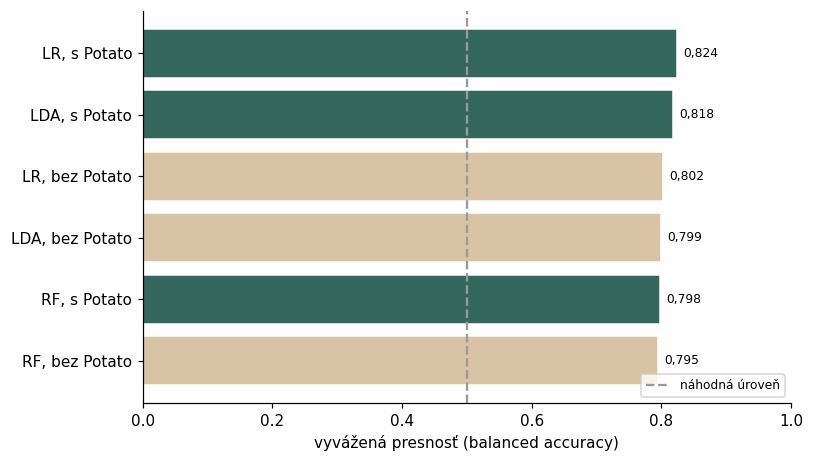

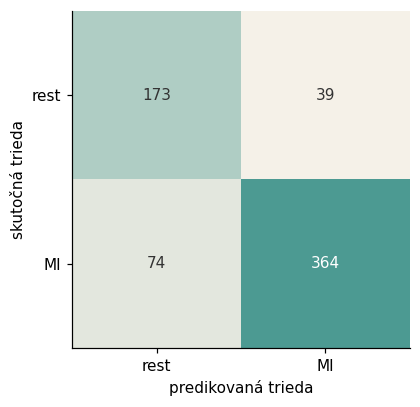

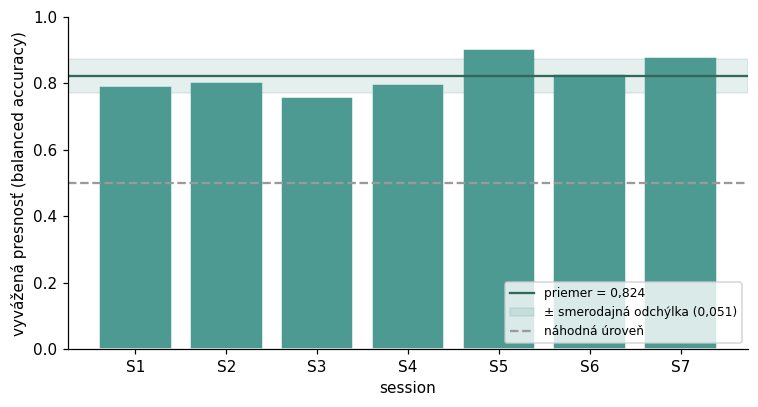

In [24]:
mi.plot_balanced_accuracy(
    rows, chance_level=CHANCE,
    save_path=FIG_DIR / "rest_vs_mi_balacc.png")

mi.plot_confusion(
    results[best["name"]]["trial_true"], results[best["name"]]["trial_pred"],
    CLASS_NAMES, save_path=FIG_DIR / "rest_vs_mi_confusion.png")

mi.plot_per_session(
    best, results, chance_level=CHANCE,
    save_path=FIG_DIR / "rest_vs_mi_per_session.png")
plt.show()